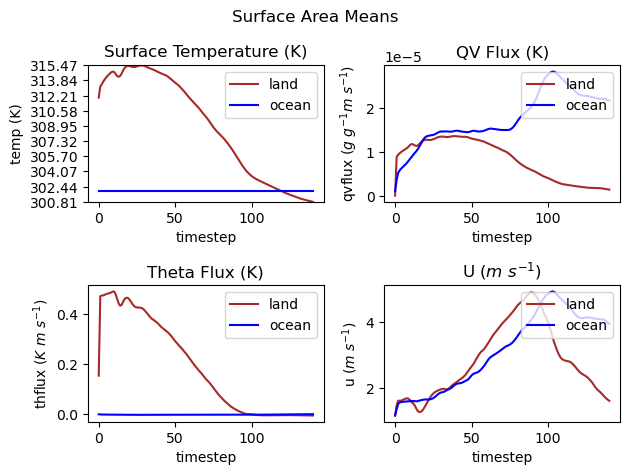

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***

plt.subplot(2,2,1)
land=slice(int(len(data['xh'])/2),int(len(data['xh'])));ocean=slice(0,int(len(data['xh'])/2)); 
land_data=data['tsk'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data=data['tsk'].isel(xh=ocean).mean(dim=['xh', 'yh'])

plt.plot(land_data,color='brown',label='land')
plt.plot(ocean_data,color='blue',label='ocean')
plt.legend(loc='upper right'); plt.title('Surface Temperature (K)')
plt.xlabel('timestep');plt.ylabel('temp (K)')
ylim = [land_data.min(),land_data.max()]
plt.ylim(ylim);plt.yticks(np.linspace(ylim[0], ylim[1], num=10))

plt.subplot(2,2,2)
land=slice(int(len(data['xh'])/2),int(len(data['xh'])));ocean=slice(0,int(len(data['xh'])/2)); 
land_data=data['qvflux'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data=data['qvflux'].isel(xh=ocean).mean(dim=['xh', 'yh'])

plt.plot(land_data,color='brown',label='land')
plt.plot(ocean_data,color='blue',label='ocean')
plt.legend(loc='upper right'); plt.title('QV Flux (K)')
plt.xlabel('timestep');plt.ylabel(r'qvflux ($g\ g^{-1} m\ s^{-1}$)')

plt.subplot(2,2,3)
land=slice(int(len(data['xh'])/2),int(len(data['xh'])));ocean=slice(0,int(len(data['xh'])/2)); 
land_data=data['thflux'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data=data['thflux'].isel(xh=ocean).mean(dim=['xh', 'yh'])

plt.plot(land_data,color='brown',label='land')
plt.plot(ocean_data,color='blue',label='ocean')
plt.legend(loc='upper right'); plt.title('Theta Flux (K)')
plt.xlabel('timestep');plt.ylabel(r'thflux ($K\ m\ s^{-1}$)')

plt.subplot(2,2,4)
land=slice(int(len(data['xf'])/2),int(len(data['xf'])));ocean=slice(0,int(len(data['xf'])/2)); 
land_data=data['u'].isel(xf=land,zh=0).mean(dim=['xf', 'yh'])
ocean_data=data['u'].isel(xf=ocean,zh=0).mean(dim=['xf', 'yh'])

plt.plot(land_data,color='brown',label='land')
plt.plot(ocean_data,color='blue',label='ocean')
plt.legend(loc='upper right'); plt.title(r'U ($m\ s^{-1}$)')
plt.xlabel('timestep');plt.ylabel(r'u ($m\ s^{-1}$)')

plt.suptitle('Surface Area Means')
plt.tight_layout()

#Please refer to campaign_data/surface_data.ipynb

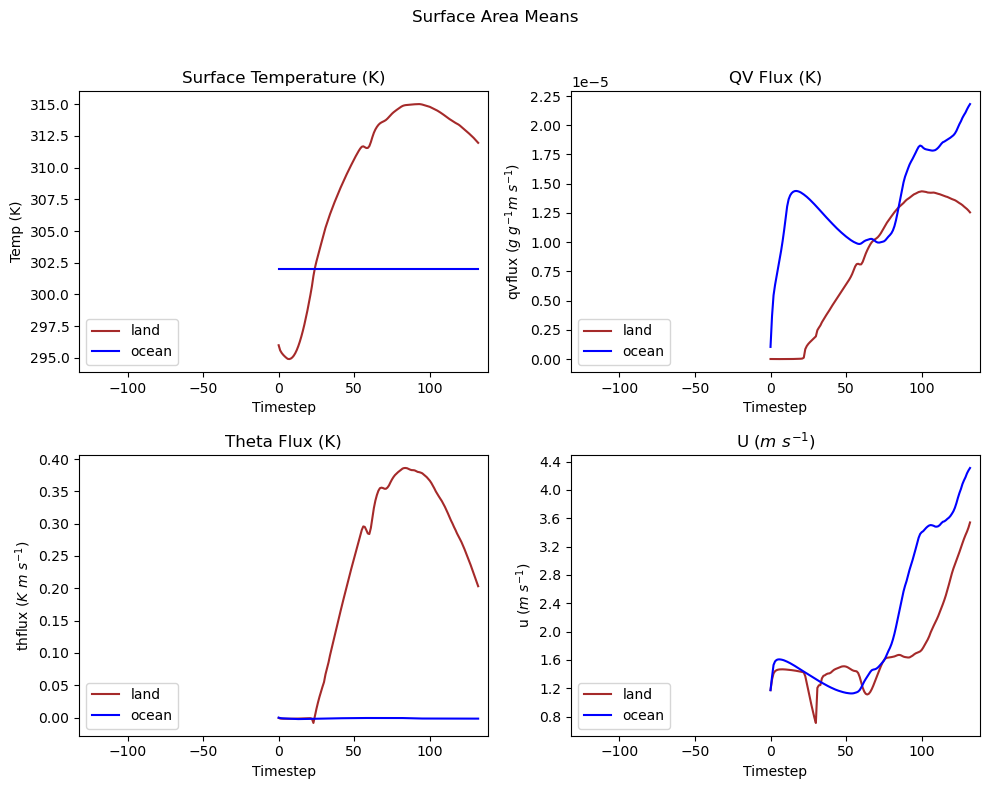

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

n_bins=10
hours_per_timestep=60/5
previous_hours=11
previous_times=-hours_per_timestep*previous_hours

# Load dataset
dir = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data = xr.open_dataset(dir + '../cm1r20.3/run/cm1out_1km_1e6.nc')  # ***

# Define land and ocean slices
fraction=0.25
land = slice(int(len(data['xh'])*fraction), int(len(data['xh'])))
ocean = slice(0, int(len(data['xh'])*fraction))

# Create figure and axes
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Surface Area Means')

# Surface Temperature Plot
ax = axes[0, 0]
land_data = data['tsk'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data = data['tsk'].isel(xh=ocean).mean(dim=['xh', 'yh'])
ax.plot(land_data, color='brown', label='land')
ax.plot(ocean_data, color='blue', label='ocean')
ax.set_title('Surface Temperature (K)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Temp (K)')
ax.legend(loc='lower left')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
ax.set_xlim(left=previous_times) #matching data diurnal cycle

# QV Flux Plot
ax = axes[0, 1]
land_data = data['qvflux'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data = data['qvflux'].isel(xh=ocean).mean(dim=['xh', 'yh'])
ax.plot(land_data, color='brown', label='land')
ax.plot(ocean_data, color='blue', label='ocean')
ax.set_title('QV Flux (K)')
ax.set_xlabel('Timestep')
ax.set_ylabel(r'qvflux ($g\ g^{-1} m\ s^{-1}$)')
ax.legend(loc='lower left')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
ax.set_xlim(left=previous_times) #matching data diurnal cycle

# Theta Flux Plot
ax = axes[1, 0]
land_data = data['thflux'].isel(xh=land).mean(dim=['xh', 'yh'])
ocean_data = data['thflux'].isel(xh=ocean).mean(dim=['xh', 'yh'])
ax.plot(land_data, color='brown', label='land')
ax.plot(ocean_data, color='blue', label='ocean')
ax.set_title('Theta Flux (K)')
ax.set_xlabel('Timestep')
ax.set_ylabel(r'thflux ($K\ m\ s^{-1}$)')
ax.legend(loc='lower left')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
ax.set_xlim(left=previous_times) #matching data diurnal cycle

# U Wind Component Plot
ax = axes[1, 1]
land_data = data['uinterp'].isel(xh=land, zh=0).mean(dim=['xh', 'yh'])
ocean_data = data['uinterp'].isel(xh=ocean, zh=0).mean(dim=['xh', 'yh'])
ax.plot(land_data, color='brown', label='land')
ax.plot(ocean_data, color='blue', label='ocean')
ax.set_title(r'U ($m\ s^{-1}$)')
ax.set_xlabel('Timestep')
ax.set_ylabel(r'u ($m\ s^{-1}$)')
ax.legend(loc='lower left')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
ax.set_xlim(left=previous_times) #matching data diurnal cycle


# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
plt.show()
